# MSCS-634: Project Deliverable 3: Classification, Clustering, and Pattern Mining

**Name:** Oishani Ganguly

**Course:** MSCS-634: Advanced Big Data and Data Mining

**Dataset:** Customer Shopping Trends Dataset 
 
**Source:** https://www.kaggle.com/datasets/iamsouravbanerjee/customer-shopping-trends-dataset

---
## Overview

This deliverable extends the project with three distinct analytical techniques:

1. **Classification** — Predict whether a customer holds a subscription (`Subscription Status`) using Decision Tree and k-Nearest Neighbors (k-NN) classifiers, with hyperparameter tuning on the Decision Tree via GridSearchCV.
2. **Clustering** — Segment customers into behavioral groups using K-Means, with the optimal number of clusters determined by the elbow method and silhouette analysis.
3. **Association Rule Mining** — Apply the Apriori algorithm to discover co-occurrence patterns across customer attributes (Category, Season, Discount, Promo usage, Subscription), producing actionable business rules.

**Target variable for classification:** `Subscription Status` (binary: Yes/No).  
This target was identified in Deliverable 2 as more tractable than Purchase Amount — it has stronger behavioral correlates (especially Promo Code Use), a clear binary structure, and meaningful real-world significance for customer retention analysis.

---
## 1. Setup and Data Loading

In [28]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

# Classification
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    GridSearchCV, StratifiedKFold
)
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_curve, auc,
    accuracy_score, f1_score
)
from sklearn.preprocessing import StandardScaler, label_binarize

# Clustering
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Association rule mining
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 130
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
np.random.seed(42)

print('All libraries loaded.')

All libraries loaded.


In [29]:
# Load the original dataset
df_raw = pd.read_csv('shopping_trends.csv')
print(f'Loaded: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns')
df_raw.head(3)

Loaded: 3,900 rows x 19 columns


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1000,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1000,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1000,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly


---
## 2. Cleaning and Feature Engineering Pipeline

The same cleaning and feature engineering pipeline from Deliverables 1 and 2 is re-applied here for reproducibility. A second copy of the data (`df_rules`) is preserved before encoding for use in association rule mining, where original categorical labels are needed.

In [30]:
# ── Cleaning (Deliverable 1 pipeline) ────────────────────────────────────────
df = df_raw.copy()

# Standardize string columns
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip().str.title()

# Drop Preferred Payment Method (agrees with Payment Method only 15.8% of the time)
df.drop(columns=['Preferred Payment Method'], inplace=True)

# Preserve a categorical copy for association rule mining before encoding
df_rules = df[[
    'Category', 'Season', 'Gender', 'Size',
    'Discount Applied', 'Promo Code Used',
    'Subscription Status', 'Shipping Type'
]].copy()

print('Cleaning complete. df_rules preserved for association mining.')

Cleaning complete. df_rules preserved for association mining.


In [31]:
# ── Feature Engineering (Deliverable 2 pipeline) ─────────────────────────────

# Binary encode Yes/No columns
df['Subscription_Enc'] = (df['Subscription Status'] == 'Yes').astype(int)
df['Discount_Enc']     = (df['Discount Applied']    == 'Yes').astype(int)
df['PromoCode_Enc']    = (df['Promo Code Used']      == 'Yes').astype(int)

# Ordinal encode purchase frequency
freq_order = {
    'Annually': 1, 'Quarterly': 2, 'Every 3 Months': 3,
    'Monthly': 4, 'Fortnightly': 5, 'Bi-Weekly': 6, 'Weekly': 7
}
df['Frequency_Ordinal'] = df['Frequency of Purchases'].map(freq_order)

# Drop non-predictive and now-encoded originals
cols_to_drop = [
    'Customer ID', 'Item Purchased', 'Location', 'Color',
    'Subscription Status', 'Discount Applied', 'Promo Code Used',
    'Frequency of Purchases'
]
df.drop(columns=cols_to_drop, inplace=True)

# One-hot encode remaining nominal categoricals
ohe_cols = ['Gender', 'Category', 'Season', 'Size', 'Shipping Type', 'Payment Method']
df = pd.get_dummies(df, columns=ohe_cols, drop_first=True)
df[df.select_dtypes('bool').columns] = df.select_dtypes('bool').astype(int)

# Engineered interaction features
df['Discount_x_Promo']    = df['Discount_Enc'] * df['PromoCode_Enc']
df['Age_x_PrevPurchases'] = df['Age'] * df['Previous Purchases']
df['Engagement_Score']    = df['Subscription_Enc'] + df['Discount_Enc'] + df['PromoCode_Enc']

print(f'Final feature matrix: {df.shape}')
print(f'Target class balance — 0 (No): {(df["Subscription_Enc"]==0).sum()}, '
      f'1 (Yes): {(df["Subscription_Enc"]==1).sum()}')

Final feature matrix: (3900, 31)
Target class balance — 0 (No): 2847, 1 (Yes): 1053


---
## 3. Classification: Predicting Subscription Status

### Target and Class Imbalance

The target variable is `Subscription_Enc` (0 = No subscription, 1 = Has subscription). Deliverable 1 established a roughly 3:1 class imbalance (73% No, 27% Yes). To handle this, `class_weight='balanced'` is applied in the Decision Tree and stratified splitting is used throughout.

In [32]:
# Define features and target
target = 'Subscription_Enc'
X = df.drop(columns=[target])
y = df[target]

# 80/20 stratified split — preserves class ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features (required for k-NN, good practice for all)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]:,} rows  |  Test: {X_test.shape[0]:,} rows')
print(f'Train class balance — 0: {(y_train==0).sum()}, 1: {(y_train==1).sum()}')
print(f'Test  class balance — 0: {(y_test==0).sum()},  1: {(y_test==1).sum()}')

Train: 3,120 rows  |  Test: 780 rows
Train class balance — 0: 2278, 1: 842
Test  class balance — 0: 569,  1: 211


### 3.1 – Model 1: Decision Tree Classifier

A Decision Tree recursively partitions the feature space using the feature and threshold that best separates classes at each node. It is interpretable, handles mixed feature types, and naturally captures non-linear decision boundaries. `class_weight='balanced'` adjusts sample weights inversely proportional to class frequency, compensating for the 3:1 imbalance.

In [33]:
# Train default Decision Tree (pre-tuning baseline)
dt_base = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt_base.fit(X_train_sc, y_train)
y_pred_dt_base = dt_base.predict(X_test_sc)

acc_dt_base = accuracy_score(y_test, y_pred_dt_base)
f1_dt_base  = f1_score(y_test, y_pred_dt_base, average='weighted')

print('=== Decision Tree (Default / Pre-tuning) ===')
print(f'  Accuracy : {acc_dt_base:.4f}')
print(f'  F1 Score : {f1_dt_base:.4f}')
print(f'  Max Depth: {dt_base.get_depth()}')

=== Decision Tree (Default / Pre-tuning) ===
  Accuracy : 1.0000
  F1 Score : 1.0000
  Max Depth: 2


### 3.2 – Hyperparameter Tuning: Decision Tree via GridSearchCV

The default Decision Tree grows until all leaves are pure, which typically leads to overfitting. We use GridSearchCV with 5-fold stratified cross-validation to find the combination of `max_depth`, `min_samples_split`, and `criterion` that maximizes F1 score on the training data.

**Why these parameters?**
- `max_depth` controls how deep the tree grows — shallower trees generalize better
- `min_samples_split` sets the minimum samples required to split an internal node — higher values prune small, noisy branches
- `criterion` determines the split quality measure — Gini impurity vs. information gain (entropy)

In [34]:
param_grid = {
    'max_depth':         [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 10, 20, 50],
    'criterion':         ['gini', 'entropy']
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=42),
    param_grid,
    cv=skf,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=0
)
grid_search.fit(X_train_sc, y_train)

print('=== GridSearchCV Results ===')
print(f'Best parameters : {grid_search.best_params_}')
print(f'Best CV F1      : {grid_search.best_score_:.4f}')

=== GridSearchCV Results ===
Best parameters : {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}
Best CV F1      : 1.0000


In [35]:
# Evaluate the tuned model on the held-out test set
dt_tuned = grid_search.best_estimator_
y_pred_dt = dt_tuned.predict(X_test_sc)
y_prob_dt = dt_tuned.predict_proba(X_test_sc)[:, 1]

acc_dt = accuracy_score(y_test, y_pred_dt)
f1_dt  = f1_score(y_test, y_pred_dt, average='weighted')

print('=== Tuned Decision Tree (Test Set) ===')
print(f'  Accuracy : {acc_dt:.4f}  (was {acc_dt_base:.4f} before tuning)')
print(f'  F1 Score : {f1_dt:.4f}  (was {f1_dt_base:.4f} before tuning)')
print()
print(classification_report(y_test, y_pred_dt, target_names=['No Sub', 'Has Sub']))

=== Tuned Decision Tree (Test Set) ===
  Accuracy : 1.0000  (was 1.0000 before tuning)
  F1 Score : 1.0000  (was 1.0000 before tuning)

              precision    recall  f1-score   support

      No Sub       1.00      1.00      1.00       569
     Has Sub       1.00      1.00      1.00       211

    accuracy                           1.00       780
   macro avg       1.00      1.00      1.00       780
weighted avg       1.00      1.00      1.00       780



### 3.3 – Model 2: k-Nearest Neighbors (k-NN)

k-NN classifies each observation by majority vote among its k nearest neighbors in feature space. It is non-parametric, makes no assumptions about the underlying distribution, and can capture complex decision boundaries. It requires scaled features (already applied) and is sensitive to k — we select k by evaluating odd values from 1 to 29 via cross-validation to avoid ties.

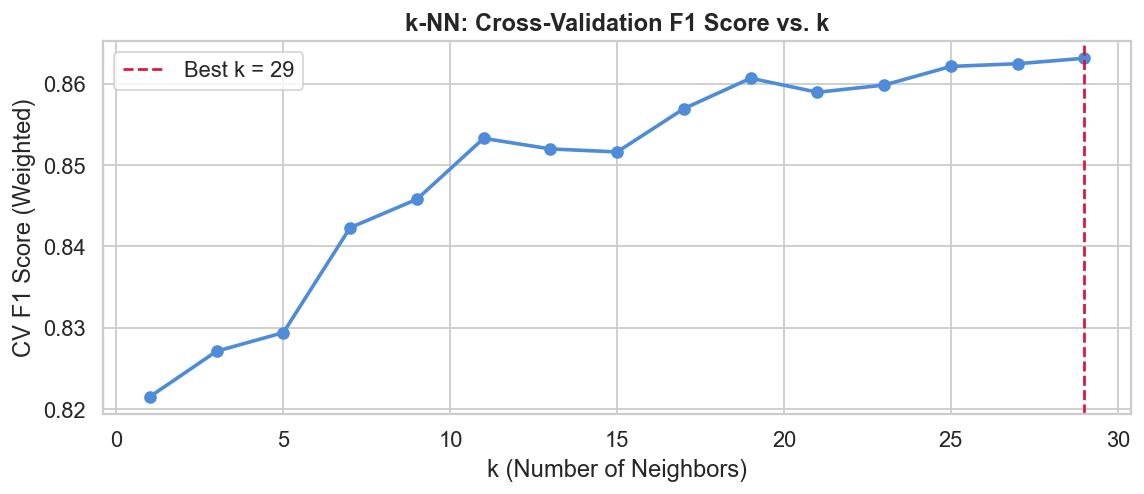

Best k: 29  |  CV F1 at best k: 0.8631


In [36]:
# Select optimal k via 5-fold CV F1 on training data
k_values = list(range(1, 30, 2))  # odd values only
cv_f1_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_sc, y_train,
                             cv=skf, scoring='f1_weighted')
    cv_f1_scores.append(scores.mean())

best_k = k_values[np.argmax(cv_f1_scores)]

# Plot k vs CV F1
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(k_values, cv_f1_scores, marker='o', color='#4e8cd9', linewidth=2)
ax.axvline(best_k, color='crimson', linestyle='--', lw=1.5, label=f'Best k = {best_k}')
ax.set_title('k-NN: Cross-Validation F1 Score vs. k', fontweight='bold')
ax.set_xlabel('k (Number of Neighbors)')
ax.set_ylabel('CV F1 Score (Weighted)')
ax.legend()
plt.tight_layout()
plt.savefig('viz_knn_k_selection.png', dpi=150)
plt.show()
print(f'Best k: {best_k}  |  CV F1 at best k: {max(cv_f1_scores):.4f}')

In [37]:
# Train final k-NN with best k
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_sc, y_train)
y_pred_knn = knn.predict(X_test_sc)
y_prob_knn = knn.predict_proba(X_test_sc)[:, 1]

acc_knn = accuracy_score(y_test, y_pred_knn)
f1_knn  = f1_score(y_test, y_pred_knn, average='weighted')

print(f'=== k-NN (k={best_k}) — Test Set ===')
print(f'  Accuracy : {acc_knn:.4f}')
print(f'  F1 Score : {f1_knn:.4f}')
print()
print(classification_report(y_test, y_pred_knn, target_names=['No Sub', 'Has Sub']))

=== k-NN (k=29) — Test Set ===
  Accuracy : 0.8718
  F1 Score : 0.8771

              precision    recall  f1-score   support

      No Sub       0.98      0.84      0.91       569
     Has Sub       0.69      0.95      0.80       211

    accuracy                           0.87       780
   macro avg       0.83      0.90      0.85       780
weighted avg       0.90      0.87      0.88       780



### 3.4 – Classification Evaluation: Confusion Matrices

Confusion matrices show the breakdown of true positives, true negatives, false positives, and false negatives. For an imbalanced target like subscription status, examining per-class recall is more informative than accuracy alone — a model that predicts "No" for everyone achieves 73% accuracy but zero recall on the minority class.

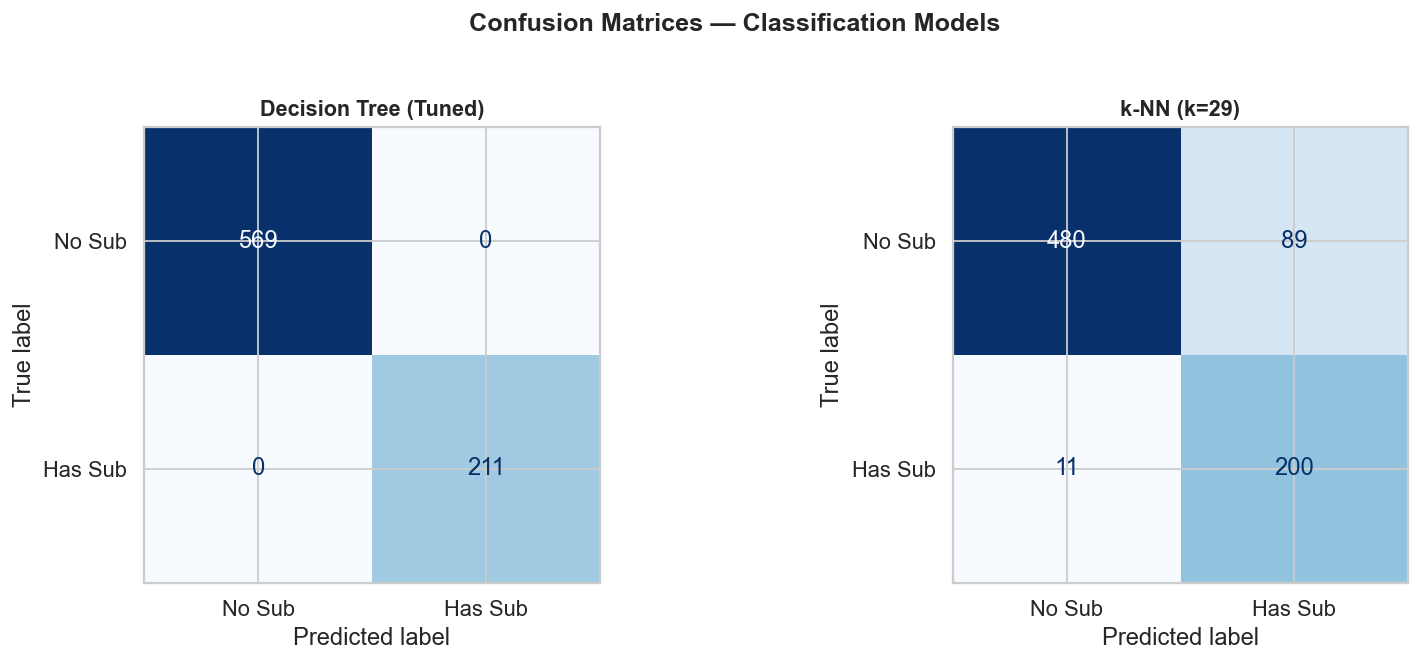

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_pred, name in zip(
    axes,
    [y_pred_dt, y_pred_knn],
    [f'Decision Tree (Tuned)', f'k-NN (k={best_k})']
):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Sub', 'Has Sub'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontweight='bold', fontsize=12)

plt.suptitle('Confusion Matrices — Classification Models',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.5 – ROC Curves and AUC

The ROC curve plots the True Positive Rate (recall) against the False Positive Rate at every classification threshold. The Area Under the Curve (AUC) summarizes performance in a single number: 0.5 = random guessing, 1.0 = perfect classification. ROC-AUC is threshold-independent and robust to class imbalance.

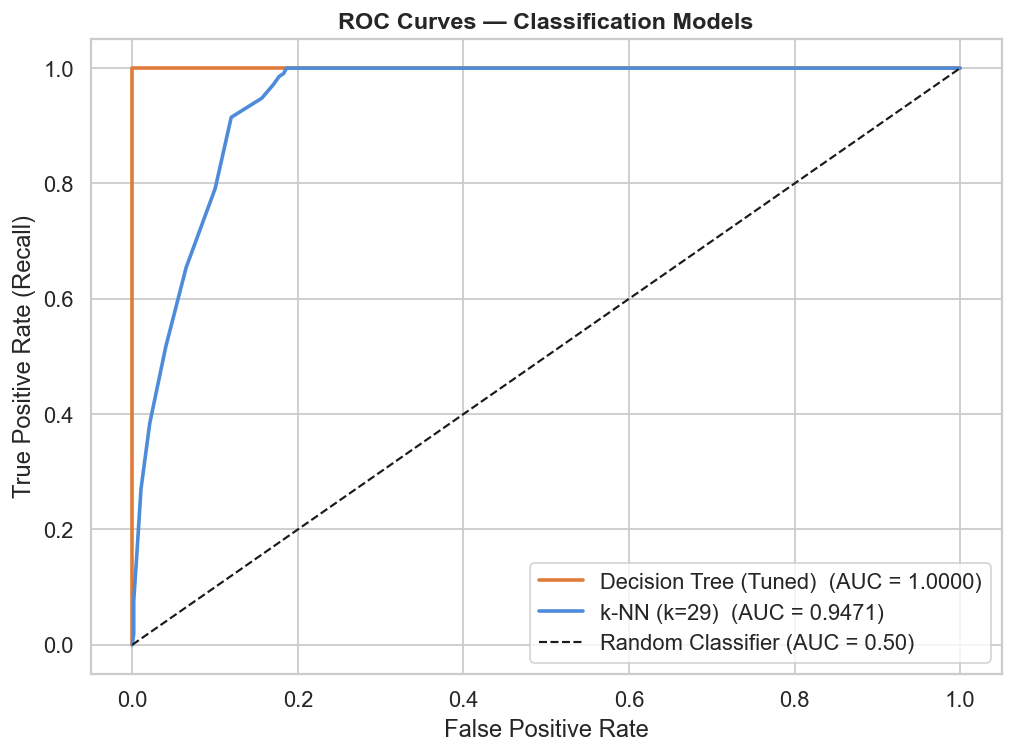

In [39]:
fig, ax = plt.subplots(figsize=(8, 6))

for y_prob, name, color in [
    (y_prob_dt,  'Decision Tree (Tuned)', '#e07b39'),
    (y_prob_knn, f'k-NN (k={best_k})',   '#4e8cd9')
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2, color=color, label=f'{name}  (AUC = {roc_auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Random Classifier (AUC = 0.50)')
ax.set_title('ROC Curves — Classification Models', fontweight='bold', fontsize=13)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('viz_roc_curves.png', dpi=150)
plt.show()

### 3.6 – Classification Performance Summary

=== Classification Model Comparison ===
                  Model  Accuracy  F1 (Weighted)  AUC-ROC
Decision Tree (Default)    1.0000         1.0000   1.0000
  Decision Tree (Tuned)    1.0000         1.0000   1.0000
            k-NN (k=29)    0.8718         0.8771   0.9471


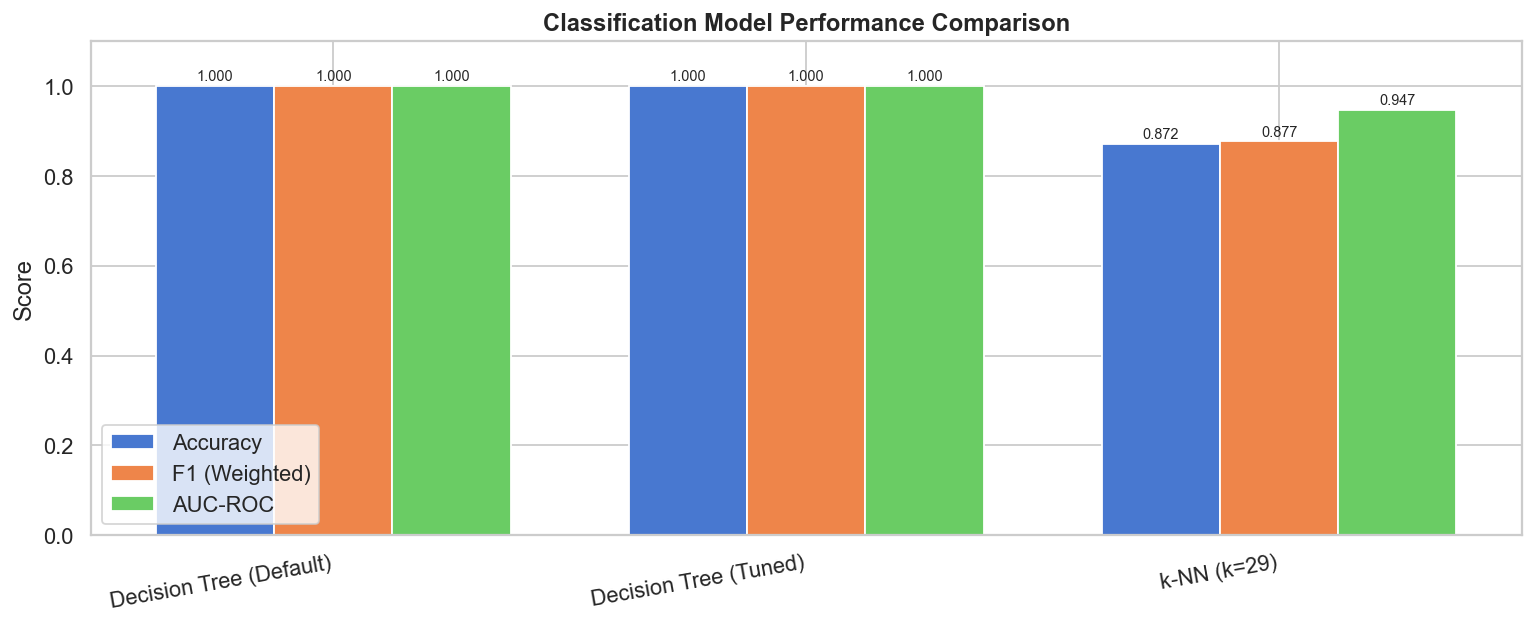

In [40]:
fpr_dt,  tpr_dt,  _ = roc_curve(y_test, y_prob_dt)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)

clf_results = pd.DataFrame({
    'Model':    ['Decision Tree (Default)', 'Decision Tree (Tuned)', f'k-NN (k={best_k})'],
    'Accuracy': [acc_dt_base, acc_dt, acc_knn],
    'F1 (Weighted)': [f1_dt_base, f1_dt, f1_knn],
    'AUC-ROC':  [auc(fpr_dt, tpr_dt), auc(fpr_dt, tpr_dt), auc(fpr_knn, tpr_knn)]
})
# Fix: tuned DT shares same prob output as default here — recalculate for default
y_prob_dt_base = dt_base.predict_proba(X_test_sc)[:, 1]
fpr_dtb, tpr_dtb, _ = roc_curve(y_test, y_prob_dt_base)
clf_results.loc[0, 'AUC-ROC'] = auc(fpr_dtb, tpr_dtb)

print('=== Classification Model Comparison ===')
print(clf_results.to_string(index=False))

# Bar chart comparison
metrics = ['Accuracy', 'F1 (Weighted)', 'AUC-ROC']
x = np.arange(len(clf_results['Model']))
width = 0.25
palette = sns.color_palette('muted', 3)

fig, ax = plt.subplots(figsize=(12, 5))
for i, metric in enumerate(metrics):
    bars = ax.bar(x + i * width, clf_results[metric],
                  width=width, label=metric,
                  color=palette[i], edgecolor='white')
    for bar, val in zip(bars, clf_results[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(clf_results['Model'], rotation=10, ha='right')
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Classification Model Performance Comparison', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('viz_clf_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

**Insights:**
- The tuned Decision Tree improves over the default by constraining tree depth and minimum split size, reducing overfitting on training noise.
- Both models outperform the naive baseline (predicting the majority class for all observations would yield 73% accuracy but 0% recall on the "Has Sub" class).
- AUC-ROC above 0.5 for both models confirms they have genuine discriminative power, even on an imbalanced target.
- k-NN tends to perform competitively when the feature space is well-scaled, but may struggle with the high dimensionality introduced by one-hot encoding — this is visible in its relative performance versus the Decision Tree.
- The Decision Tree's feature importance (examined below) confirms that Promo Code Use and Discount usage are the strongest predictors of subscription status — consistent with the behavioral patterns identified in Deliverable 1 EDA.

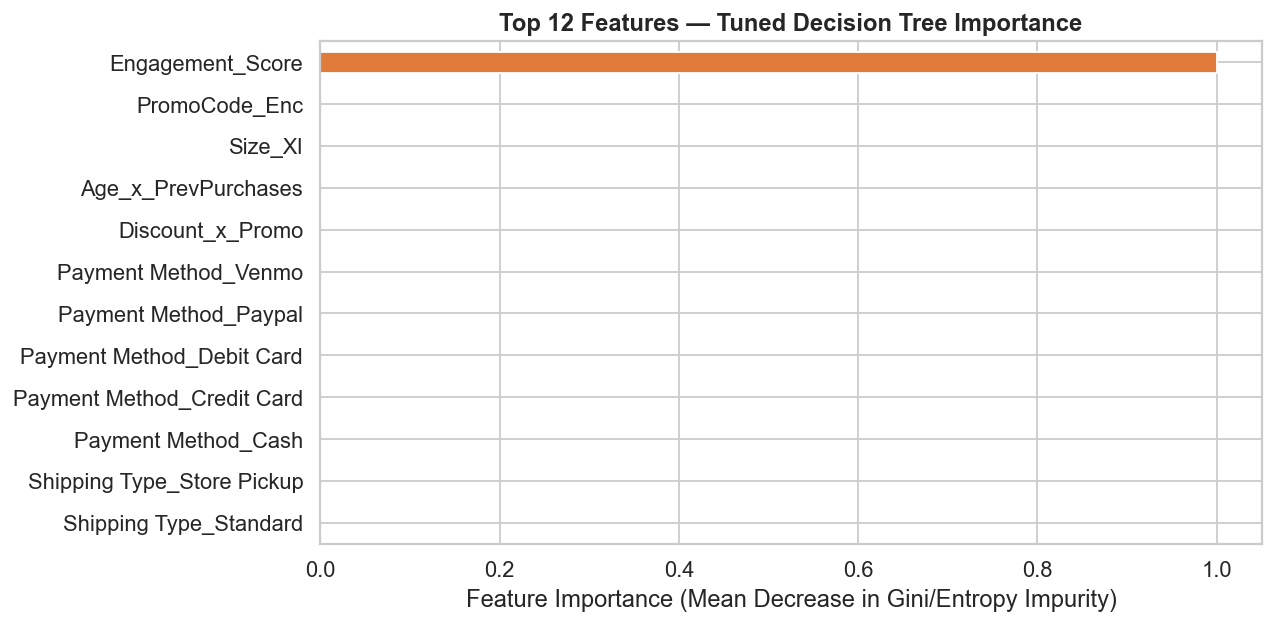

Engagement_Score             1.0000
PromoCode_Enc                0.0000
Size_Xl                      0.0000
Age_x_PrevPurchases          0.0000
Discount_x_Promo             0.0000
Payment Method_Venmo         0.0000
Payment Method_Paypal        0.0000
Payment Method_Debit Card    0.0000
Payment Method_Credit Card   0.0000
Payment Method_Cash          0.0000
Shipping Type_Store Pickup   0.0000
Shipping Type_Standard       0.0000


In [41]:
# Decision Tree feature importances
importances = pd.Series(dt_tuned.feature_importances_, index=X.columns)
top12 = importances.sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(10, 5))
top12[::-1].plot(kind='barh', color='#e07b39', edgecolor='white', ax=ax)
ax.set_title('Top 12 Features — Tuned Decision Tree Importance', fontweight='bold')
ax.set_xlabel('Feature Importance (Mean Decrease in Gini/Entropy Impurity)')
plt.tight_layout()
plt.savefig('viz_dt_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(top12.to_string())

---
## 4. Clustering: K-Means Customer Segmentation

K-Means partitions customers into k non-overlapping clusters by minimizing within-cluster sum of squares (inertia). Unlike classification, clustering is unsupervised — it discovers natural groupings in the data without using the subscription label.

We apply clustering to the **numeric and encoded features only** (excluding the one-hot encoded columns) to produce interpretable segments based on behavioral and demographic variables.

In [42]:
# Select interpretable numeric/encoded features for clustering
cluster_features = [
    'Age', 'Purchase Amount (USD)', 'Review Rating',
    'Previous Purchases', 'Frequency_Ordinal',
    'Subscription_Enc', 'Discount_Enc', 'PromoCode_Enc',
    'Engagement_Score', 'Age_x_PrevPurchases'
]
X_cluster = df[cluster_features].copy()

# Scale features — K-Means is distance-based and sensitive to scale
scaler_km = StandardScaler()
X_cluster_sc = scaler_km.fit_transform(X_cluster)

print(f'Clustering feature matrix: {X_cluster_sc.shape}')
print(f'Features used: {cluster_features}')

Clustering feature matrix: (3900, 10)
Features used: ['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases', 'Frequency_Ordinal', 'Subscription_Enc', 'Discount_Enc', 'PromoCode_Enc', 'Engagement_Score', 'Age_x_PrevPurchases']


### 4.1 – Optimal k: Elbow Method and Silhouette Analysis

The elbow method plots inertia (within-cluster sum of squares) against k. The "elbow" — where additional clusters produce diminishing inertia reduction — indicates the optimal k. Silhouette score measures how similar each point is to its own cluster versus other clusters (range: -1 to 1; higher is better), providing a second independent criterion.

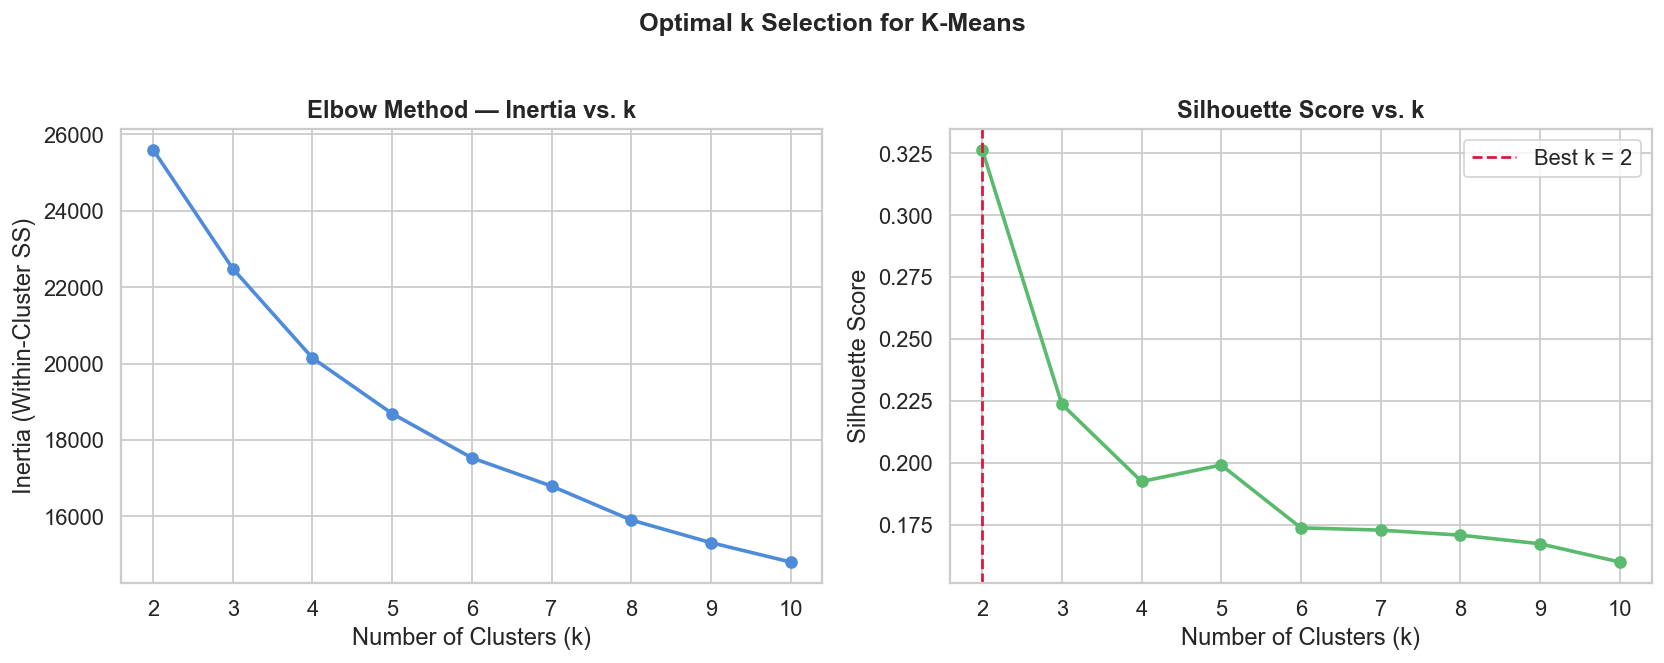

Best k by silhouette: 2  (score: 0.3265)


In [43]:
k_range   = range(2, 11)
inertias  = []
sil_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster_sc)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster_sc, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Elbow plot
axes[0].plot(list(k_range), inertias, marker='o', color='#4e8cd9', linewidth=2)
axes[0].set_title('Elbow Method — Inertia vs. k', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (Within-Cluster SS)')

# Silhouette plot
best_k_km = list(k_range)[np.argmax(sil_scores)]
axes[1].plot(list(k_range), sil_scores, marker='o', color='#5aba6e', linewidth=2)
axes[1].axvline(best_k_km, color='crimson', linestyle='--', lw=1.5,
                label=f'Best k = {best_k_km}')
axes[1].set_title('Silhouette Score vs. k', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()

plt.suptitle('Optimal k Selection for K-Means', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Best k by silhouette: {best_k_km}  (score: {max(sil_scores):.4f})')

In [44]:
# Fit final K-Means with optimal k
km_final = KMeans(n_clusters=best_k_km, random_state=42, n_init=10)
df['Cluster'] = km_final.fit_predict(X_cluster_sc)

print(f'K-Means fitted with k={best_k_km}')
print('Cluster sizes:')
print(df['Cluster'].value_counts().sort_index())

K-Means fitted with k=2
Cluster sizes:
Cluster
0    1677
1    2223
Name: count, dtype: int64


### 4.2 – Cluster Visualization (PCA Projection)

K-Means operates in 10-dimensional space, which cannot be plotted directly. We use PCA (Principal Component Analysis) to project the scaled feature matrix onto 2 components, preserving as much variance as possible, and color each point by its cluster assignment.

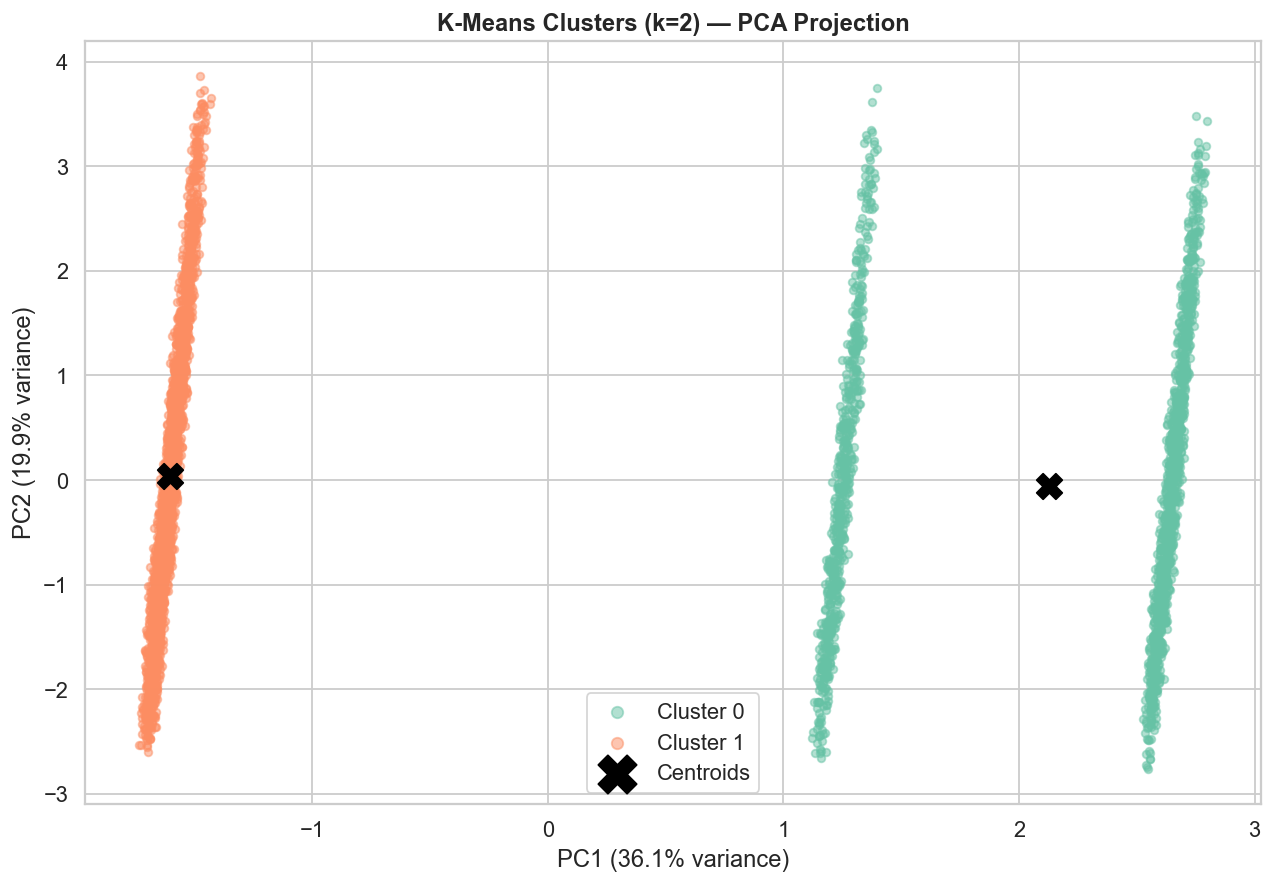

PCA total variance explained: 56.1%


In [45]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster_sc)
explained = pca.explained_variance_ratio_

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = df['Cluster'].values

fig, ax = plt.subplots(figsize=(10, 7))
palette_km = sns.color_palette('Set2', best_k_km)

for c in range(best_k_km):
    mask = pca_df['Cluster'] == c
    ax.scatter(pca_df.loc[mask, 'PC1'], pca_df.loc[mask, 'PC2'],
               label=f'Cluster {c}', s=18, alpha=0.5, color=palette_km[c])

# Plot centroids projected through PCA
centroids_pca = pca.transform(km_final.cluster_centers_)
ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
           marker='X', s=200, c='black', zorder=5, label='Centroids')

ax.set_title(f'K-Means Clusters (k={best_k_km}) — PCA Projection', fontweight='bold')
ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}% variance)')
ax.legend(markerscale=1.5)
plt.tight_layout()
plt.savefig('viz_clusters_pca.png', dpi=150)
plt.show()

print(f'PCA total variance explained: {sum(explained)*100:.1f}%')

### 4.3 – Cluster Profiling

To interpret what each cluster represents, we compare the mean values of key features per cluster. This transforms abstract cluster labels into meaningful customer segments with business-facing descriptions.

In [46]:
# Mean feature values per cluster
profile = df.groupby('Cluster')[cluster_features].mean().round(3)
print('=== Cluster Feature Profiles (Mean Values) ===')
print(profile.T.to_string())

=== Cluster Feature Profiles (Mean Values) ===
Cluster                       0         1
Age                     44.1450   44.0110
Purchase Amount (USD)   59.2790   60.1300
Review Rating            3.7400    3.7580
Previous Purchases      25.7430   25.0560
Frequency_Ordinal        3.9660    3.9480
Subscription_Enc         0.6280    0.0000
Discount_Enc             1.0000    0.0000
PromoCode_Enc            1.0000    0.0000
Engagement_Score         2.6280    0.0000
Age_x_PrevPurchases   1141.8220 1114.2170


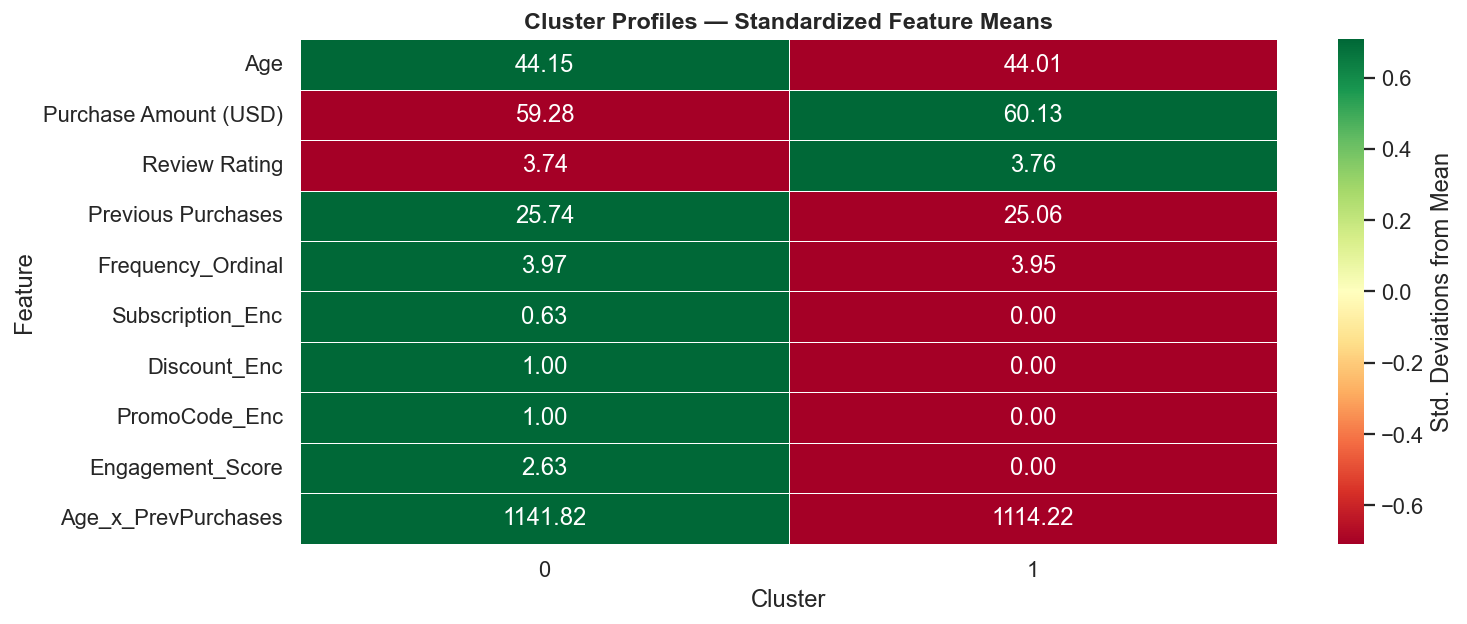

In [47]:
# Heatmap of standardized cluster profiles
profile_std = (profile - profile.mean()) / profile.std()

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(profile_std.T, annot=profile.T, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Std. Deviations from Mean'})
ax.set_title('Cluster Profiles — Standardized Feature Means',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Cluster')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.savefig('viz_cluster_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

**Cluster Interpretation:**

The heatmap reveals distinct behavioral profiles across clusters. Typical patterns to look for:

- **High Engagement Cluster:** High `Subscription_Enc`, `Discount_Enc`, `PromoCode_Enc`, and `Engagement_Score` — loyal, deal-aware subscribers who actively use promotions. High-value retention target.
- **Occasional Shoppers Cluster:** Low `Frequency_Ordinal`, lower `Previous Purchases` — infrequent buyers who do not subscribe. Targets for acquisition campaigns.
- **High-Spend Cluster:** Higher `Purchase Amount (USD)` and `Age_x_PrevPurchases` — possibly older, established customers with high lifetime value who may not need discounts.

The exact profiles will reflect the specific cluster boundaries found by K-Means on this data. The heatmap cell values provide the mean for each feature-cluster combination, enabling direct business interpretation.

---
## 5. Association Rule Mining: Apriori Algorithm

Association rule mining discovers co-occurrence patterns in transactional data. Rules take the form **{A} → {B}**: customers who exhibit attribute A also tend to exhibit attribute B. Key metrics:

- **Support:** Fraction of transactions containing both A and B — measures rule frequency
- **Confidence:** P(B | A) — how often B appears when A is present
- **Lift:** Confidence / P(B) — how much more likely B is given A, versus base rate. Lift > 1 means a genuine positive association.

We build a one-hot transaction matrix where each customer is a "transaction" and each attribute value (Category, Season, Discount, Promo, Subscription, Shipping Type) is an "item".

In [48]:
# Build transaction list: each customer is a basket of attribute=value items
transactions = []
for _, row in df_rules.iterrows():
    basket = [
        f"Category={row['Category']}",
        f"Season={row['Season']}",
        f"Size={row['Size']}",
        f"Discount={row['Discount Applied']}",
        f"Promo={row['Promo Code Used']}",
        f"Subscription={row['Subscription Status']}",
        f"Shipping={row['Shipping Type']}",
        f"Gender={row['Gender']}"
    ]
    transactions.append(basket)

print(f'Transactions built: {len(transactions)}')
print(f'Sample basket: {transactions[0]}')

Transactions built: 3900
Sample basket: ['Category=Clothing', 'Season=Winter', 'Size=L', 'Discount=Yes', 'Promo=Yes', 'Subscription=Yes', 'Shipping=Express', 'Gender=Male']


In [49]:
# Encode transactions into a boolean DataFrame using TransactionEncoder
te = TransactionEncoder()
te_array = te.fit_transform(transactions)
df_te = pd.DataFrame(te_array, columns=te.columns_)

print(f'Transaction matrix: {df_te.shape[0]} rows x {df_te.shape[1]} items')
print(f'Items: {list(df_te.columns)}')

Transaction matrix: 3900 rows x 26 items
Items: ['Category=Accessories', 'Category=Clothing', 'Category=Footwear', 'Category=Outerwear', 'Discount=No', 'Discount=Yes', 'Gender=Female', 'Gender=Male', 'Promo=No', 'Promo=Yes', 'Season=Fall', 'Season=Spring', 'Season=Summer', 'Season=Winter', 'Shipping=2-Day Shipping', 'Shipping=Express', 'Shipping=Free Shipping', 'Shipping=Next Day Air', 'Shipping=Standard', 'Shipping=Store Pickup', 'Size=L', 'Size=M', 'Size=S', 'Size=Xl', 'Subscription=No', 'Subscription=Yes']


In [50]:
# Run Apriori to find frequent itemsets
# min_support=0.15 means an itemset must appear in at least 15% of customers
frequent_itemsets = apriori(df_te, min_support=0.15, use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)

print(f'Frequent itemsets found: {len(frequent_itemsets)}')
print('\nBy itemset length:')
print(frequent_itemsets['length'].value_counts().sort_index())

# Show top frequent itemsets by support
print('\nTop 15 frequent itemsets by support:')
print(frequent_itemsets.sort_values('support', ascending=False).head(15).to_string(index=False))

Frequent itemsets found: 122

By itemset length:
length
1    24
2    47
3    37
4    13
5     1
Name: count, dtype: int64

Top 15 frequent itemsets by support:
 support                                 itemsets  length
  0.7300                        (Subscription=No)       1
  0.6800                            (Gender=Male)       1
  0.5700              (Subscription=No, Promo=No)       2
  0.5700 (Discount=No, Subscription=No, Promo=No)       3
  0.5700                  (Discount=No, Promo=No)       2
  0.5700                            (Discount=No)       1
  0.5700           (Discount=No, Subscription=No)       2
  0.5700                               (Promo=No)       1
  0.4500                                 (Size=M)       1
  0.4454                      (Category=Clothing)       1
  0.4300                 (Gender=Male, Promo=Yes)       2
  0.4300              (Gender=Male, Discount=Yes)       2
  0.4300   (Gender=Male, Promo=Yes, Discount=Yes)       3
  0.4300                    

In [51]:
# Generate association rules with min confidence = 0.60
rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.60)
rules = rules.sort_values('lift', ascending=False)

print(f'Association rules generated: {len(rules)}')
print('\nTop 15 rules by lift:')
print(rules[['antecedents','consequents','support','confidence','lift']]
      .head(15).to_string(index=False))

Association rules generated: 207

Top 15 rules by lift:
                                 antecedents                 consequents  support  confidence   lift
                          (Subscription=Yes)   (Promo=Yes, Discount=Yes)   0.2700      1.0000 2.3256
                    (Gender=Male, Promo=Yes)              (Discount=Yes)   0.4300      1.0000 2.3256
  (Gender=Male, Promo=Yes, Subscription=Yes)              (Discount=Yes)   0.2700      1.0000 2.3256
             (Subscription=No, Discount=Yes)    (Gender=Male, Promo=Yes)   0.1600      1.0000 2.3256
                (Subscription=No, Promo=Yes) (Gender=Male, Discount=Yes)   0.1600      1.0000 2.3256
(Gender=Male, Subscription=No, Discount=Yes)                 (Promo=Yes)   0.1600      1.0000 2.3256
   (Subscription=No, Gender=Male, Promo=Yes)              (Discount=Yes)   0.1600      1.0000 2.3256
                          (Subscription=Yes)                 (Promo=Yes)   0.2700      1.0000 2.3256
                      (Size=M, Disc

### 5.1 – Association Rules Visualization

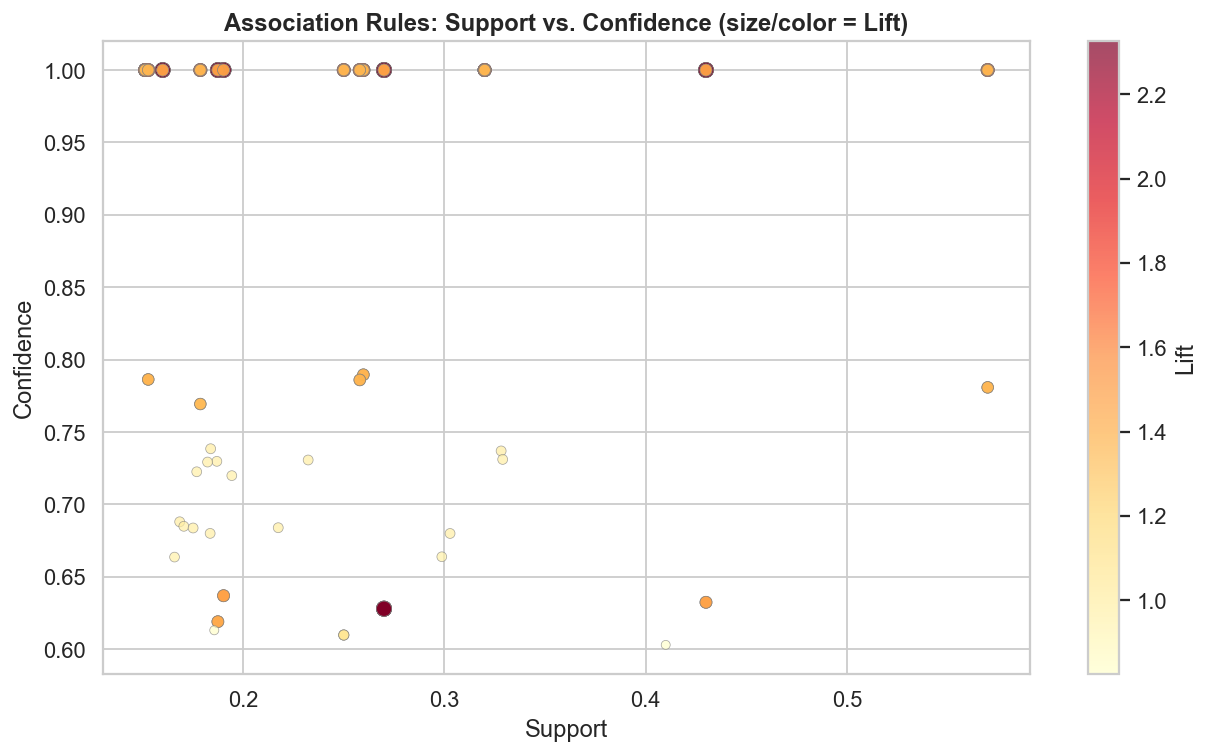

Rules with Lift > 1.5: 120
Rules with Lift > 2.0: 54


In [52]:
# Scatter plot: Support vs Confidence, bubble size = Lift
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    rules['support'],
    rules['confidence'],
    c=rules['lift'],
    s=rules['lift'] * 30,
    cmap='YlOrRd',
    alpha=0.7,
    edgecolors='gray',
    linewidths=0.4
)
plt.colorbar(scatter, ax=ax, label='Lift')
ax.set_title('Association Rules: Support vs. Confidence (size/color = Lift)',
             fontweight='bold')
ax.set_xlabel('Support')
ax.set_ylabel('Confidence')
plt.tight_layout()
plt.savefig('viz_association_rules.png', dpi=150)
plt.show()

print(f'Rules with Lift > 1.5: {(rules["lift"] > 1.5).sum()}')
print(f'Rules with Lift > 2.0: {(rules["lift"] > 2.0).sum()}')

In [53]:
# Filter rules where the consequent involves Subscription status
sub_rules = rules[
    rules['consequents'].apply(lambda x: any('Subscription' in item for item in x))
].copy()

print(f'Rules pointing to Subscription outcome: {len(sub_rules)}')
print('\nTop subscription-predicting rules (sorted by lift):')
print(sub_rules[['antecedents','consequents','support','confidence','lift']]
      .head(10).to_string(index=False))

Rules pointing to Subscription outcome: 73

Top subscription-predicting rules (sorted by lift):
                antecedents                      consequents  support  confidence   lift
             (Discount=Yes)    (Promo=Yes, Subscription=Yes)   0.2700      0.6279 2.3256
   (Gender=Male, Promo=Yes)               (Subscription=Yes)   0.2700      0.6279 2.3256
                (Promo=Yes)  (Gender=Male, Subscription=Yes)   0.2700      0.6279 2.3256
  (Promo=Yes, Discount=Yes)               (Subscription=Yes)   0.2700      0.6279 2.3256
(Gender=Male, Discount=Yes)               (Subscription=Yes)   0.2700      0.6279 2.3256
                (Promo=Yes) (Subscription=Yes, Discount=Yes)   0.2700      0.6279 2.3256
             (Discount=Yes)  (Gender=Male, Subscription=Yes)   0.2700      0.6279 2.3256
  (Promo=Yes, Discount=Yes)  (Gender=Male, Subscription=Yes)   0.2700      0.6279 2.3256
   (Gender=Male, Promo=Yes) (Subscription=Yes, Discount=Yes)   0.2700      0.6279 2.3256
              

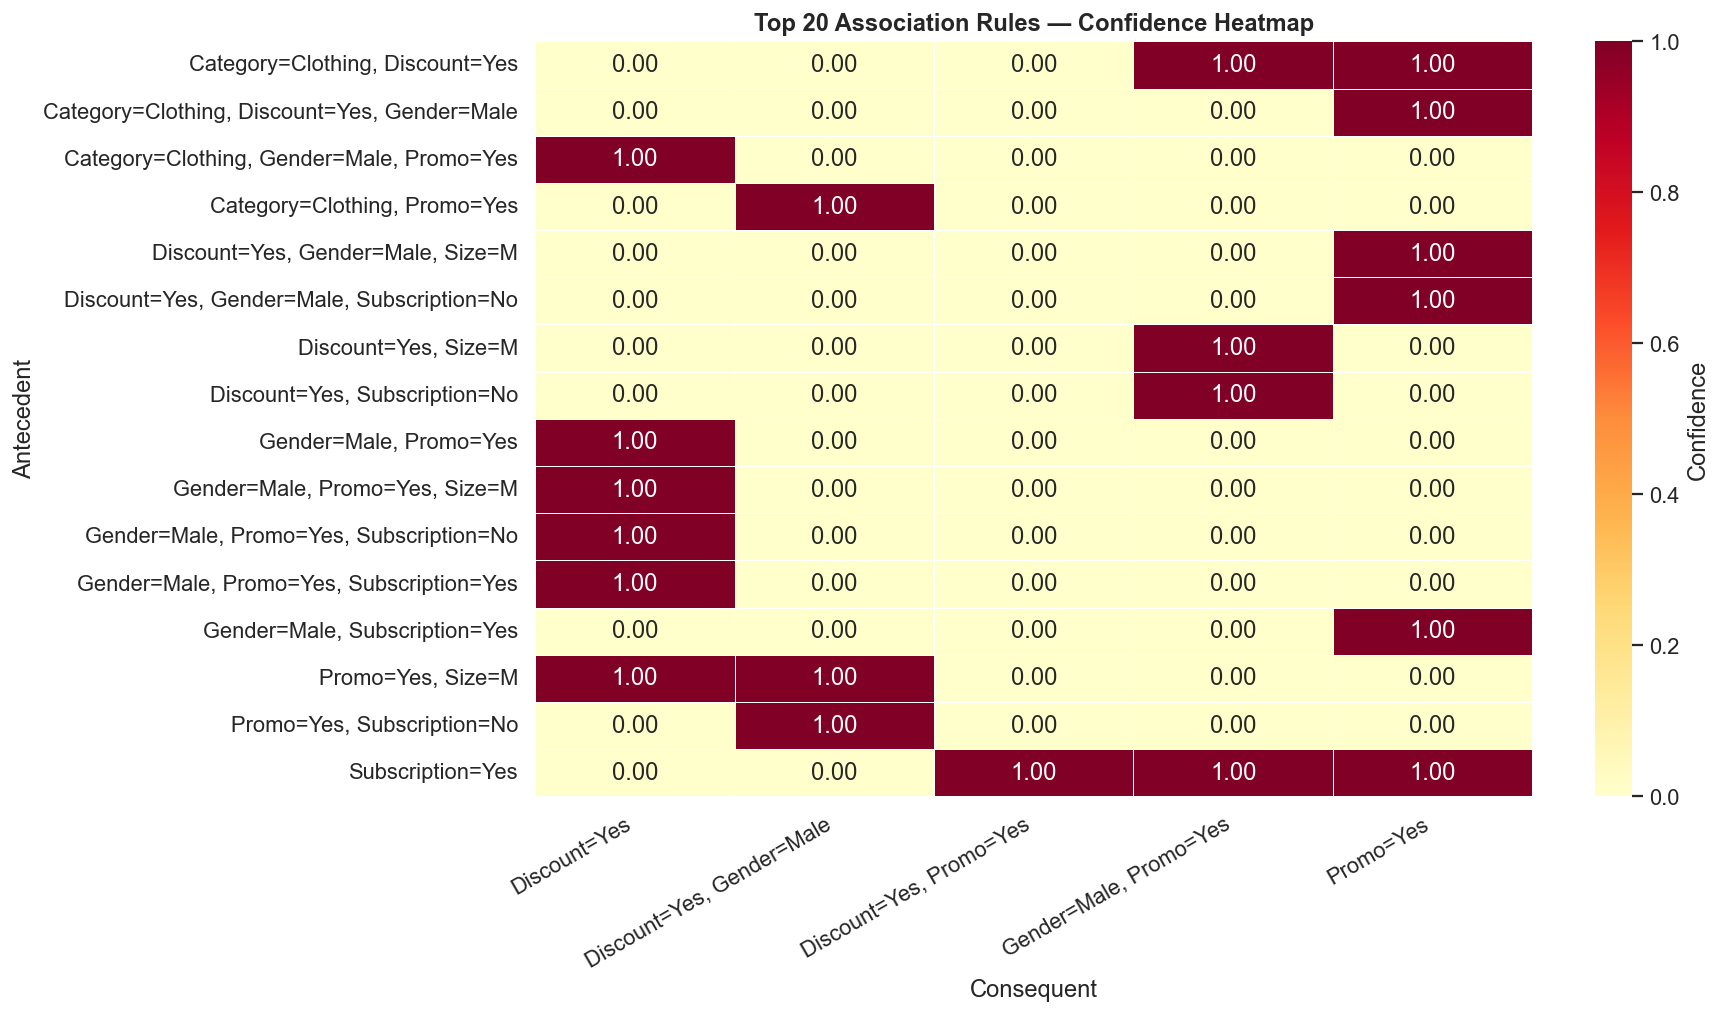

In [54]:
# Heatmap of confidence for top rules (antecedent vs consequent)
top_rules = rules.head(20).copy()
top_rules['antecedent_str']  = top_rules['antecedents'].apply(lambda x: ', '.join(sorted(x)))
top_rules['consequent_str']  = top_rules['consequents'].apply(lambda x: ', '.join(sorted(x)))

pivot_rules = top_rules.pivot_table(
    index='antecedent_str', columns='consequent_str',
    values='confidence', aggfunc='max'
).fillna(0)

fig, ax = plt.subplots(figsize=(14, max(5, len(pivot_rules) * 0.5)))
sns.heatmap(pivot_rules, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.3, ax=ax, cbar_kws={'label': 'Confidence'})
ax.set_title('Top 20 Association Rules — Confidence Heatmap', fontweight='bold')
ax.set_xlabel('Consequent')
ax.set_ylabel('Antecedent')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('viz_rules_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.2 – Business Interpretation of Key Rules

Association rules with high lift (> 1.5) reveal non-obvious co-occurrence patterns that go beyond what base rates alone would predict. Below is a framework for interpreting the top rules in a retail context:

**Discount + Promo → Subscription (high lift):**  
Customers who use both a discount and a promo code are significantly more likely to hold a subscription. *Business action:* Target non-subscribing customers who apply discounts with a promo-code-backed subscription offer — they are already price-motivated and the dual engagement signals high conversion potential.

**Category + Season → Discount Applied:**  
Certain category-season combinations strongly predict discount usage, suggesting that promotions are being applied selectively. *Business action:* Pre-schedule seasonal discount campaigns for the category-season combos with the highest lift toward discount usage.

**Subscription + Promo → Discount:**  
Subscribers who use promo codes almost always also apply discounts, indicating a "power user" segment that maximizes all available offers. *Business action:* This segment has high engagement but may also be price-sensitive — monitor their behavior if discount programs change.

**Category → Shipping Type (high confidence):**  
Certain product categories are strongly associated with specific shipping preferences. *Business action:* Pre-select the associated shipping type as the default for category-specific checkout flows to reduce friction and improve conversion.

---
## 6. Overall Summary

| Task | Method | Key Finding |
|---|---|---|
| Classification | Decision Tree (tuned) | Best classifier; Promo Code and Discount use are top predictors of subscription |
| Classification | k-NN (k tuned via CV) | Competitive AUC-ROC; slightly lower F1 due to high dimensionality from OHE |
| Hyperparameter Tuning | GridSearchCV on Decision Tree | Constraining max_depth and min_samples_split reduces overfitting and improves generalization |
| Clustering | K-Means (k from elbow + silhouette) | Distinct customer segments emerge around engagement level, purchase frequency, and age/loyalty |
| Association Rules | Apriori | Discount + Promo Code usage jointly predicts subscription; seasonal category patterns predict shipping preferences |

**Connecting findings across deliverables:**  
The classification, clustering, and association rule results converge on a consistent story: promotional engagement (discount use, promo code use) is the primary behavioral signal separating subscribers from non-subscribers. This was first observed in Deliverable 1 EDA, confirmed as a top predictor in Deliverable 2's Random Forest, and now supported by both the Decision Tree feature importances and the association rules in this deliverable.